In [1]:
%cd /Users/floriankokoszka/Desktop/notebooks
%pwd

%run mc_startup.ipynb
%run myfunctions.ipynb

import os

import geopandas as gpd
#cities = gpd.read_file(gpd.datasets.get_path('naturalearth_cities'))
#cities.head()
#http://www.xavierdupre.fr/app/papierstat/helpsphinx/notebooks/enedis_cartes.html#geopandas


def iserror(func, *args, **kw):
    try:
        func(*args, **kw)
        return False
    except Exception:
        return True

def isfloat(num):
    try:
        float(num)
        return True
    except ValueError:
        return False
    
    
import scipy.io as sio


/Users/floriankokoszka/Desktop/notebooks


In [2]:
####### DATA PATH
#####
###
#
data_pth = '/Volumes/DENISE/data/glider/teresa/data/' 
meta_pth = '/Volumes/DENISE/data/glider/teresa/meta/' 

In [5]:
dir_list = os.listdir(data_pth)
dirs = []
for i in range(0,len(dir_list)):
    if dir_list[i].startswith('.') == False:
        dirs.append(dir_list[i])
dir_list = np.array(dirs)
dir_list

array(['teresa_microrider_2015_agosto', 'teresa_microrider_2015_july',
       'teresa_microrider_2017_marzo_aprile',
       'teresa_microrider_2017_MISC', 'teresa_microrider_2018_maggio',
       'teresa_microrider_2022', 'teresa_microrider_2023'], dtype='<U35')

In [6]:
import glob
import os
import time

M = []
P = []
F = []

for d in range(0,len(dir_list)):
    dir_pth = data_pth + dir_list[d] +'/data/'
    print(dir_pth)
    
    #----------------------------------
    file_typ = '.P'
    liste = filter( os.path.isfile, glob.glob(dir_pth + '*'+file_typ) )
    liste = sorted( liste,key = os.path.getmtime)
    for file_path in liste:
        timestamp_str = time.strftime('%m/%d/%Y :: %H:%M:%S',time.gmtime(os.path.getmtime(file_path))) 
    liste_P = liste
    #
    P_liste = []
    for i in range(0,len(liste_P)):
        P_liste.append(liste_P[i].split('/')[-1][0:-2])
     
    #----------------------------------
    file_typ = '.mat'
    liste = filter( os.path.isfile, glob.glob(dir_pth + '*'+file_typ) )
    liste = sorted( liste,key = os.path.getmtime)
    for file_path in liste:
        timestamp_str = time.strftime('%m/%d/%Y :: %H:%M:%S',time.gmtime(os.path.getmtime(file_path))) 
    liste_MAT = liste
    #
    MAT_liste = []
    for i in range(0,len(liste_MAT)):
        MAT_liste.append(liste_MAT[i].split('/')[-1][0:-4])
    
    #----------------------------------
    liste_FAIL = []
    for i in range(0,len(P_liste)):
        if (P_liste[i] in MAT_liste) == False:
            liste_FAIL.append(liste_P[i])
     
    #----------------------------------
    P = P + liste_P 
    M = M + liste_MAT
    F = F + liste_FAIL 

FS = []
for i in range(0,len(M)):
    file_size = os.stat((M[i]))
    #print("file size :", file_size.st_size/1e6, "M bytes")
    FS.append(file_size.st_size/1e6)
FS = np.array(FS)

print('\n:',len(M),'x .mat files')
print('total of ',np.round(np.nansum(FS)/1e3,0).astype(int),'Go of .mat')


FS = []
for i in range(0,len(P)):
    file_size = os.stat((P[i]))
    #print("file size :", file_size.st_size/1e6, "M bytes")
    FS.append(file_size.st_size/1e6)
FS = np.array(FS)

print('\n:',len(P),'x .P files')
print('total of ',np.round(np.nansum(FS)/1e3,0).astype(int),' Go of .P files')


/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2015_agosto/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2015_july/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2017_marzo_aprile/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2017_MISC/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2018_maggio/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2022/data/
/Volumes/DENISE/data/glider/teresa/data/teresa_microrider_2023/data/

: 657 x .mat files
total of  601 Go of .mat

: 922 x .P files
total of  99  Go of .P files


In [13]:
# print the lists

pth = meta_pth+'/lists/'

L = M
lname = 'liste_MAT.txt'
file_object = open(pth+lname, 'w')
file_object.close()
#
file_object = open(pth+lname, 'a')
file_object.write(str(len(L))+' files \n')
file_object.close()
#
for l in range(0,len(L)):
    file_object = open(pth+lname, 'a')
    file_object.write(L[l]+'\n')
    file_object.close()

    
L = P
lname = 'liste_P.txt'
file_object = open(pth+lname, 'w')
file_object.close()
#
file_object = open(pth+lname, 'a')
file_object.write(str(len(L))+' files \n')
file_object.close()

for l in range(0,len(L)):
    file_object = open(pth+lname, 'a')
    file_object.write(L[l]+'\n')
    file_object.close()
    
    
L = F
lname = 'liste_FAIL.txt'
file_object = open(pth+lname, 'w')
file_object.close()
#
file_object = open(pth+lname, 'a')
file_object.write(str(len(L))+' files \n')
file_object.close()

for l in range(0,len(L)):
    file_object = open(pth+lname, 'a')
    file_object.write(L[l]+'\n')
    file_object.close()

In [291]:
from scipy.signal import argrelextrema


columnz = ['fn','fnshort','date','time','N_slow','N_fast','delta_t',
           'P_min','P_max','P_mean','P_std',
           'T2_min','T2_max','T2_mean','T2_std',
           'T1_min','T1_max','T1_mean','T1_std',
    'Tfast_min','Tfast_max','Tfast_mean','Tfast_std',
    'W_min','W_max','W_mean','W_std',
    'speed_min','speed_max','speed_mean','speed_std',
    'sh1_min','sh1_max','sh1_mean','sh1_std',
    'sh2_min','sh2_max','sh2_mean','sh2_std',
    'V_Bat_min','V_Bat_max','V_Bat_mean','V_Bat_std',
    'Incl_Y_min','Incl_Y_max','Incl_Y_mean','Incl_Y_std',
    'Incl_X_min','Incl_X_max','Incl_X_mean','Incl_X_std',
    'N_profiles_downward_fast','N_profiles_upward_fast',
        'peaks_fast_i','peaks_fast_e','difpres_fast',
        'N_profiles_downward_slow','N_profiles_upward_slow',
        'peaks_slow_i','peaks_slow_e','difpres_slow',
        'setupfilestr']

i0 = 0
i0 = 321
custom_liste = np.concatenate((np.arange(0,320),np.arange(321,len(M))),0)

META = []
for ii in range(0,len(custom_liste)):
    
    per = np.round((ii / len(custom_liste)) * 100 ,1) 
    if per % 2.0 == 0:
        print(f"Progress : {per}%")
    
    i = custom_liste[ii]
    fn = str(M[i])
    fnshort = fn.split('/')[-1][0:-4]
    # # # # # # # 
    matstruct_contents = sio.loadmat(fn)
    # # # # # # # 
    
    
    # short -----------------------------------------
    setupfilestr = matstruct_contents['setupfilestr']
    
    t_slow = np.array(matstruct_contents['t_slow']).flatten()
    t_fast = np.array(matstruct_contents['t_fast']).flatten()

    date = np.array(matstruct_contents['date'])[0]
    time = np.array(matstruct_contents['time'])[0]
    T1_slow = np.array(matstruct_contents['T1_slow']).flatten()
    T2_slow = np.array(matstruct_contents['T2_slow']).flatten()
    P_slow = np.array(matstruct_contents['P_slow']).flatten()
    W_slow = np.array(matstruct_contents['W_slow']).flatten()
    speed_slow = np.array(matstruct_contents['speed_slow']).flatten()

    sh1 = np.array(matstruct_contents['sh1']).flatten()
    sh2 = np.array(matstruct_contents['sh2']).flatten()
    temperature_fast = np.array(matstruct_contents['temperature_fast']).flatten()
    P_fast = np.array(matstruct_contents['P_fast']).flatten()

    V_Bat = np.array(matstruct_contents['V_Bat']).flatten()
    Incl_Y = np.array(matstruct_contents['Incl_Y']).flatten()
    Incl_X = np.array(matstruct_contents['Incl_X']).flatten()


    # light -----------------------------------------
    t_i = np.arange(t_slow[0],t_slow[-1],1)
    P_i = interpholes(t_slow,P_slow,t_i)
    T2_i = interpholes(t_slow,T2_slow,t_i)
    T1_i = interpholes(t_slow,T1_slow,t_i)
    W_i = interpholes(t_slow,W_slow,t_i)
    speed_i = interpholes(t_slow,speed_slow,t_i)
    
    V_Bat_i = interpholes(t_slow,V_Bat,t_i)
    Incl_Y_i = interpholes(t_slow,Incl_Y,t_i)
    Incl_X_i = interpholes(t_slow,Incl_X,t_i)
    
    
    sh1_i = interpholes(t_fast,sh1,t_i)
    sh2_i = interpholes(t_fast,sh2,t_i)
    temperature_fast_i = interpholes(t_fast,temperature_fast,t_i)
    
    
    #--------- PROFILES ? ----------------------------
    from scipy.signal import argrelextrema

    ithresh = 10000
    #------
    y_data = P_slow
    peaks_ind = argrelextrema(y_data,np.less)
    peaks_ind = peaks_ind[0]
    f = np.where(np.diff(peaks_ind)> ithresh)[0]
    peaks_ind = peaks_ind[f]
    peaks_ind = list(peaks_ind)
    peaks_ind.append(len(t_slow)-1)
    peaks_slow = np.array(peaks_ind)

    #------
    y_data = P_fast
    peaks_ind = argrelextrema(y_data,np.less)
    peaks_ind = peaks_ind[0]
    f = np.where(np.diff(peaks_ind)> ithresh*10)[0]
    peaks_ind = peaks_ind[f]
    peaks_ind = list(peaks_ind)
    peaks_ind.append(len(t_fast)-1)
    peaks_fast = np.array(peaks_ind)


    if len(peaks_fast) == 1:
        peaks_fast = np.concatenate(([0],peaks_fast),axis=0)
        peaks_slow = np.concatenate(([0],peaks_slow),axis=0)

    peaks_fast_i = peaks_fast[0:-1]
    peaks_fast_e = peaks_fast[1:]
    difpres_fast = np.diff(P_fast[peaks_fast])
    #print(len(difpres_fast))
    f = np.where(difpres_fast > 0)[0]
    N_profiles_downward_fast = len(f)
    f = np.where(difpres_fast < 0)[0]
    N_profiles_upward_fast = len(f)
    
    peaks_slow_i = peaks_slow[0:-1]
    peaks_slow_e = peaks_slow[1:]
    difpres_slow = np.diff(P_slow[peaks_slow])
    #print(len(difpres_slow))
    f = np.where(difpres_slow > 0)[0]
    N_profiles_downward_slow = len(f)
    f = np.where(difpres_slow < 0)[0]
    N_profiles_upward_slow = len(f)
    
    



    wantplot = 1 
    if wantplot == 1:
        # plot -----------------------------------------
        fig , axs =  plt.subplots(1,4, figsize=(15,3))

        ax = axs[0]
        ax.plot(t_i,P_i,'k')
        ax.invert_yaxis()
        ax.set_title(date+' '+time+' '+fn.split('/')[-1])
        ax.set_ylabel('Pressure $(db)$')
        ax.set_xlabel('Time $(s)$')
        ax.grid(alpha=.25)
        ax.plot(t_slow[peaks_slow],P_slow[peaks_slow],'ro')

        ax = axs[1]
        ax.plot(sh1_i,P_i,color='b',label='sh1 i',alpha=.5)
        ax.plot(sh2_i,P_i,color='r',label='sh2 i',alpha=.5)
        ax.invert_yaxis()
        ax.set_ylabel('Pressure $(db)$')
        ax.set_xlabel('sh $(s^{-1})$')
        ax.legend(fontsize=8)
        ax.grid(alpha=.25)

        ax = axs[2]
        ax.plot(temperature_fast_i,P_i,color='b',label='Temp fast i',alpha=.5)
        ax.invert_yaxis()
        ax.set_ylabel('Pressure $(db)$')
        ax.set_xlabel('T $(C^{o})$')
        ax.legend(fontsize=8)
        ax.grid(alpha=.25)

        ax = axs[3]
        ax.hist(T1_i,bins=np.arange(10,35,0.1),color='b',label='T1 i',alpha=.5)
        ax.hist(T2_i,bins=np.arange(10,35,0.1),color='r',label='T2 i',alpha=.5)
        ax.set_title('')
        ax.set_xlabel('T $(C^{o})$')
        ax.legend(fontsize=8)
        ax.grid(alpha=.25)

        figname = date+'_'+fn.split('/')[-1][0:-4]
        fig.tight_layout(pad=1)
        fig.savefig(meta_pth+'plots/'+ figname+ '.pdf')
        plt.close(fig)
        
       
    #-------------------------
    fn
    fnshort
    date
    time

    N_slow = len(t_slow)
    N_fast = len(t_fast)

    delta_t = (t_i[-1]-t_i[0])

    x = P_i*1
    P_min = np.nanmin(x)
    P_max = np.nanmax(x)
    P_mean = np.nanmean(x)
    P_std = np.nanstd(x)
    
    x = T2_i*1
    T2_min  = np.nanmin(x)
    T2_max  = np.nanmax(x)
    T2_mean = np.nanmean(x)
    T2_std  = np.nanstd(x)

    x = T1_i*1
    T1_min = np.nanmin(x)
    T1_max = np.nanmax(x)
    T1_mean = np.nanmean(x)
    T1_std = np.nanstd(x)


    x = temperature_fast_i*1
    Tfast_min = np.nanmin(x)
    Tfast_max = np.nanmax(x)
    Tfast_mean = np.nanmean(x)
    Tfast_std = np.nanstd(x)
    
    x = W_i*1
    W_min = np.nanmin(x)
    W_max = np.nanmax(x)
    W_mean = np.nanmean(x)
    W_std = np.nanstd(x)


    x = speed_i*1
    speed_min = np.nanmin(x)
    speed_max = np.nanmax(x)
    speed_mean = np.nanmean(x)
    speed_std = np.nanstd(x)

    x = sh1_i*1
    sh1_min = np.nanmin(x)
    sh1_max = np.nanmax(x)
    sh1_mean = np.nanmean(x)
    sh1_std = np.nanstd(x)

    x = sh2_i*1
    sh2_min = np.nanmin(x)
    sh2_max = np.nanmax(x)
    sh2_mean = np.nanmean(x)
    sh2_std = np.nanstd(x)


    x = V_Bat_i*1
    V_Bat_min = np.nanmin(x)
    V_Bat_max = np.nanmax(x)
    V_Bat_mean = np.nanmean(x)
    V_Bat_std = np.nanstd(x)

    x = Incl_Y_i*1
    Incl_Y_min = np.nanmin(x)
    Incl_Y_max = np.nanmax(x)
    Incl_Y_mean = np.nanmean(x)
    Incl_Y_std = np.nanstd(x)

    x = Incl_X_i*1
    Incl_X_min = np.nanmin(x)
    Incl_X_max = np.nanmax(x)
    Incl_X_mean = np.nanmean(x)
    Incl_X_std = np.nanstd(x)

    #
    #-------------------------
        
    
    meta = [fn,fnshort,date,time,N_slow,N_fast,delta_t,
        P_min, P_max, P_mean,P_std,
        T2_min,T2_max,T2_mean,T2_std,
        T1_min,T1_max,T1_mean,T1_std,
        Tfast_min,Tfast_max,Tfast_mean,Tfast_std,
        W_min,W_max,W_mean,W_std,
        speed_min,speed_max,speed_mean,speed_std,
        sh1_min,sh1_max,sh1_mean,sh1_std,
        sh2_min,sh2_max,sh2_mean,sh2_std,
        V_Bat_min,V_Bat_max,V_Bat_mean,V_Bat_std,
        Incl_Y_min,Incl_Y_max,Incl_Y_mean,Incl_Y_std,
        Incl_X_min,Incl_X_max,Incl_X_mean,Incl_X_std,
    
        N_profiles_downward_fast,N_profiles_upward_fast,
        peaks_fast_i,peaks_fast_e,difpres_fast,
        N_profiles_downward_slow,N_profiles_upward_slow,
        peaks_slow_i,peaks_slow_e,difpres_slow,
        setupfilestr]
    
    
    META.append(meta)
print('LOOP FINISHED')

META = pd.DataFrame(META)
META.set_axis(columnz, axis="columns", inplace=True)
META.sort_values(by='date', inplace = True) 

META.to_csv(meta_pth+'/META.csv', index = False)
print('META STEP DONE')   

Progress : 0.0%
Progress : 2.0%
Progress : 4.0%
Progress : 12.0%
Progress : 14.0%
Progress : 16.0%
Progress : 18.0%
Progress : 20.0%
Progress : 22.0%
Progress : 28.0%
Progress : 30.0%
Progress : 32.0%
Progress : 34.0%
Progress : 36.0%
Progress : 38.0%
Progress : 46.0%
Progress : 48.0%
Progress : 50.0%
Progress : 52.0%
Progress : 54.0%
Progress : 62.0%
Progress : 64.0%
Progress : 66.0%
Progress : 68.0%
Progress : 70.0%
Progress : 72.0%
Progress : 78.0%
Progress : 80.0%
Progress : 82.0%
Progress : 84.0%
Progress : 86.0%
Progress : 88.0%
Progress : 96.0%
Progress : 98.0%
LOOP FINISHED
META STEP DONE


In [381]:
META = pd.read_csv(meta_pth+'/META.csv') 


In [380]:
META.sort_values(by='date', inplace = True) 
META.to_csv(meta_pth+'/META.csv', index = False)

AttributeError: 'NoneType' object has no attribute 'shape'

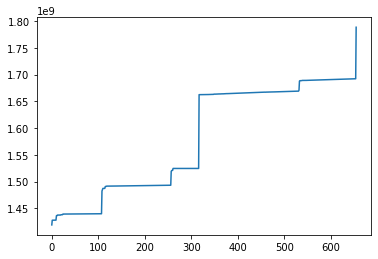

In [389]:
date = np.array(META['date'])
time = np.array(META['time'])
#
DT = []
TS = []
yyyy = []
mm = []
dd = []
HH = []
MM = []
SS = []
for i in range(0,len(date)):
    dt = datetime.strptime(date[i]+' '+time[i][0:-4], "%Y-%m-%d %H:%M:%S")
    DT.append(dt)
    yyyy.append(dt.year)
    mm.append(dt.month)
    dd.append(dt.day)
    HH.append(dt.hour)
    MM.append(dt.minute)
    SS.append(dt.second)
    TS.append(dt.timestamp())
    
DT = np.array(DT)
TS = np.array(TS)
yyyy = np.array(yyyy)
mm = np.array(mm)
dd = np.array(dd)
HH = np.array(HH)
MM = np.array(MM)
SS = np.array(SS)

yyyymm = yyyy + mm/13
ud = np.unique(yyyy)
F = []
for u in range(0,len(ud)):
    f = np.where(yyyy == ud[u])[0][0]
    F.append(f)
F = np.array(F)

plt.plot(TS)

In [383]:
META.columns

Index(['fn', 'fnshort', 'date', 'time', 'N_slow', 'N_fast', 'delta_t', 'P_min',
       'P_max', 'P_mean', 'P_std', 'T2_min', 'T2_max', 'T2_mean', 'T2_std',
       'T1_min', 'T1_max', 'T1_mean', 'T1_std', 'Tfast_min', 'Tfast_max',
       'Tfast_mean', 'Tfast_std', 'W_min', 'W_max', 'W_mean', 'W_std',
       'speed_min', 'speed_max', 'speed_mean', 'speed_std', 'sh1_min',
       'sh1_max', 'sh1_mean', 'sh1_std', 'sh2_min', 'sh2_max', 'sh2_mean',
       'sh2_std', 'V_Bat_min', 'V_Bat_max', 'V_Bat_mean', 'V_Bat_std',
       'Incl_Y_min', 'Incl_Y_max', 'Incl_Y_mean', 'Incl_Y_std', 'Incl_X_min',
       'Incl_X_max', 'Incl_X_mean', 'Incl_X_std', 'N_profiles_downward_fast',
       'N_profiles_upward_fast', 'peaks_fast_i', 'peaks_fast_e',
       'difpres_fast', 'N_profiles_downward_slow', 'N_profiles_upward_slow',
       'peaks_slow_i', 'peaks_slow_e', 'difpres_slow', 'setupfilestr'],
      dtype='object')

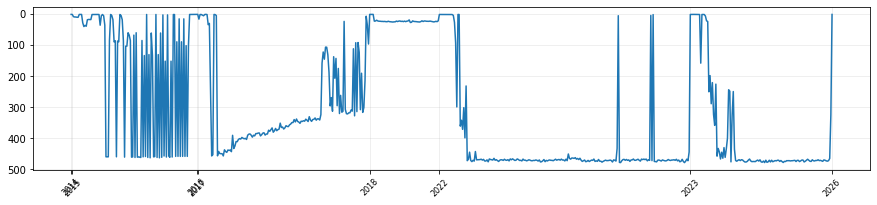

In [391]:
fig , axs =  plt.subplots(1,1, figsize=(15,3))

ax = axs
ax.plot(META['P_mean'])
#ax.plot(META['sh2_mean'])

ax.invert_yaxis()
#ax.set_title(date+' '+time+' '+fn.split('/')[-1])
#ax.set_ylabel('Pressure $(db)$')
#ax.set_xlabel('Time $(s)$')
ax.set_xticks(F)
ax.set_xticklabels(np.round(yyyy[F],2),fontsize=8,rotation=45)

#ax.set_xlim(450,500)
ax.grid(alpha=.25)

In [359]:
yyyy[F]

array([2014, 2015, 2016, 2017, 2018, 2022, 2023, 2026])